In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd

data = yf.download("RELIANCE.NS", start="2024-01-01", end="2026-07-01")
print(data.head())

/tmp/ipykernel_4209/3848091452.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("RELIANCE.NS", start="2024-01-01", end="2026-07-01")
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2024-01-01  1279.692993  1287.894143  1271.244822  1274.900807     4030540
2024-01-02  1290.290039  1291.920403  1271.170629  1277.099136     7448800
2024-01-03  1276.259277  1301.307194  1273.245572  1289.450180     9037536
2024-01-04  1282.854614  1289.376068  1274.184270  1278.581198     9612778
2024-01-05  1288.313843  1294.316528  1283.521657  1285.942416     8086406


In [3]:
# flatten the column structure first (avoids errors later)
data.columns = data.columns.get_level_values(0)

data['Daily_Return'] = data['Close'].pct_change()
data['MA_30'] = data['Close'].rolling(window=30).mean()
data['Volatility'] = data['Daily_Return'].rolling(window=30).std()

print(data.tail())

Price             Close         High          Low         Open    Volume  \
Date                                                                       
2026-06-24  1313.599976  1322.000000  1297.500000  1305.699951  11030917   
2026-06-25  1318.099976  1328.000000  1314.599976  1318.000000  12694362   
2026-06-26  1318.099976  1318.099976  1318.099976  1318.099976         0   
2026-06-29  1301.000000  1313.699951  1292.599976  1308.000000  13757656   
2026-06-30  1293.900024  1306.900024  1290.000000  1306.900024  15695263   

Price       Daily_Return        MA_30  Volatility  
Date                                               
2026-06-24      0.003131  1317.100977    0.011875  
2026-06-25      0.003426  1315.853223    0.011888  
2026-06-26      0.000000  1315.448238    0.011403  
2026-06-29     -0.012973  1314.489844    0.011638  
2026-06-30     -0.005457  1313.732764    0.011545  


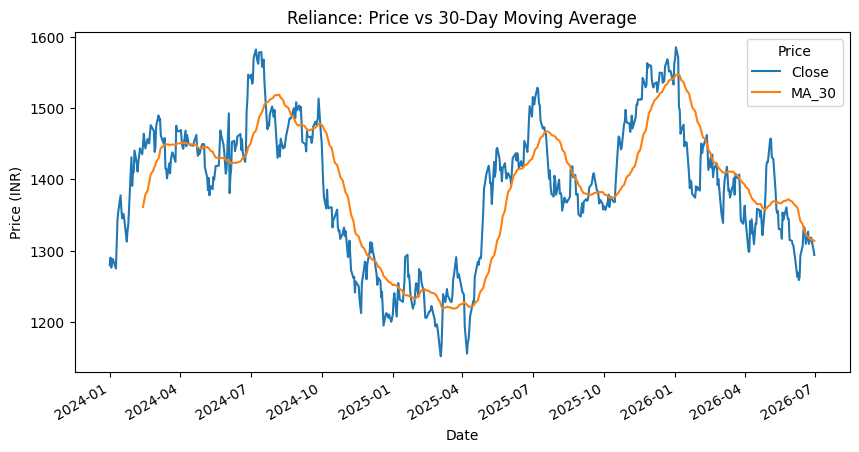

In [4]:
import matplotlib.pyplot as plt

data[['Close', 'MA_30']].plot(figsize=(10,5), title="Reliance: Price vs 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.show()